In [1]:
import json
import pandas as pd
from pathlib import Path

from utils import plot_aerial_boxplot, plot_aquatic_boxplot, plot_multiple_boxplots, plot_combined_boxplots

In [2]:
base_path = Path("../results/10_run_26_01_06")

In [3]:
results_path = base_path / "all_runs_results.json"

if not results_path.exists():
    raise FileNotFoundError("Arquivo all_runs_results.json não encontrado.")

# Carregar os resultados
with open(results_path, "r") as f:
    results = json.load(f)

# Construir lista de dicts para o DataFrame
rows = []

for run in results:
    run_id = run["run_id"]
    if not run["success"]:
        print(f"[WARN] Execução {run_id} falhou — ignorando.")
        continue

    pareto = run["pareto_front"]  # lista de pares [aerial, aquatic]

    for (aerial, aquatic) in pareto:
        rows.append({
            "run_id": run_id,
            "aerial_fitness": aerial,
            "aquatic_fitness": aquatic,
        })

# DataFrame
df = pd.DataFrame(rows)
df.head()

,run_id,aerial_fitness,aquatic_fitness
0,8,2.791825,1.701541
1,8,2.789809,1.882015
2,8,2.759921,1.886849
3,8,2.753236,1.889107
4,8,2.746307,1.903378


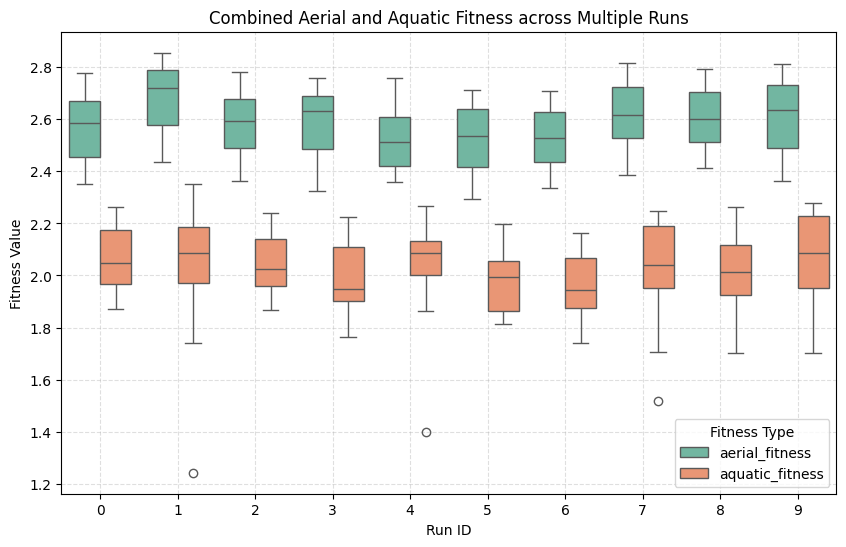

In [4]:
plot_combined_boxplots(df)